# UK Politics

This dataset from Kaggle contains 3 datasets: one with speeches extracted from britishpolicalspeech.org (12k rows), one with speeches from ukpol.co.uk (350 rows) and one with the UK members of parliament since 1970, including party affiliation, obtained from Wikidata.

# Data exploratory

In [1]:
import pandas as pd
from tqdm import tqdm
import numpy as np
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/corentin/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/corentin/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [2]:
df_speeches = pd.read_csv('./data/speeches_ukpol.csv')
df_speeches.drop(columns=df_speeches.columns[0], axis=1, inplace=True)
df_speeches.head()

,Speaker,Year,Description,Speech
0,Diane Abbott,NaN,Below is the text of the speech made by Diane ...,The fact that the House of Commons has spent t...
1,Diane Abbott,2018.0,Below is the text of the speech made by Diane ...,Thank you Chair. Thank you Conference. It’s gr...
2,Diane Abbott,2019.0,Below is the text of the speech made by Diane ...,I thank the Home Secretary for his account of ...
3,Diane Abbott,2020.0,Below is the text of the speech made by Diane ...,"We live in extraordinary times. Unfortunately,..."
4,Diane Abbott,2020.0,Below is the text of the speech made by Diane ...,Like my good friend the right hon. Member for ...


In [3]:
df_speakers = pd.read_csv('./data/MPs_1970_onwards.csv')
df_speakers.head()

,item,itemLabel,constituencyLabel,partyLabel,start,electionLabel,end,endcauseLabel,noteLabel
0,http://www.wikidata.org/entity/Q265935,Nick Brown,Newcastle upon Tyne East,independent politician,2022-09-07T00:00:00Z,2019 United Kingdom general election,NaN,NaN,NaN
1,http://www.wikidata.org/entity/Q580464,Penny Mordaunt,NaN,NaN,2022-09-06T00:00:00Z,NaN,NaN,NaN,NaN
2,http://www.wikidata.org/entity/Q303299,Tobias Ellwood,Bournemouth East,independent politician,2022-07-19T00:00:00Z,NaN,NaN,NaN,NaN
3,http://www.wikidata.org/entity/Q575266,Christopher Pincher,Tamworth,independent politician,2022-06-30T00:00:00Z,NaN,NaN,NaN,NaN
4,http://www.wikidata.org/entity/Q19883135,Patrick Grady,Glasgow North,independent politician,2022-06-26T00:00:00Z,NaN,NaN,NaN,NaN


In [4]:
def binarize_party(label):
    if label == 'Labour Party':
        return 0
    elif label == 'Conservative Party':
        return 1
    else:
        return None

In [5]:
df_speakers['party'] = df_speakers['partyLabel'].apply(binarize_party)

In [6]:
df_speakers = df_speakers[['itemLabel', 'party']].groupby('itemLabel').mean().reset_index()

In [7]:
df_speakers = df_speakers[df_speakers['party'].isin([0, 1, np.nan])]

In [8]:
df_speakers.rename(columns={'itemLabel': 'Speaker'}, inplace=True)

In [9]:
df_merged = pd.merge(df_speeches, df_speakers, on='Speaker')

In [10]:
indexes_to_drop = [275, 429, 1575, 1929, 1930, 1931, 3309, 3310, 3629, 3688, 4686, 4842, 4994, 5474, 5475, 5508, 5526, 5581, 5597, 5601, 5611, 6097, 6279, 6609, 7820, 8192, 8289]
df_merged = df_merged.drop(index=indexes_to_drop)

In [11]:
df_merged = df_merged.dropna(subset=['Speaker', 'Speech'])
df_merged = df_merged[(df_merged['Speaker'] != '') & (df_merged['Speech'] != '') & (df_merged['party'] != '')]
df_merged = df_merged[df_merged['Year'] >= 1970]

In [12]:
len(df_merged)

9919

# Preprocessing NLP

Extracting the speeches column

In [13]:
speeches = df_merged['Speech'].values.tolist()

In [14]:
speeches = [element.lower() for element in speeches]

Splitting the words for each speech

In [15]:
def tokenize(speeches):
    speeches_token = []
    for speech in tqdm(speeches):
        speeches_token.append(nltk.tokenize.word_tokenize(speech))
    return speeches_token

In [16]:
speeches = tokenize(speeches)

100%|██████████| 9919/9919 [00:22<00:00, 449.12it/s]


In [17]:
speeches[0]

['thank',
 'you',
 'chair',
 '.',
 'thank',
 'you',
 'conference',
 '.',
 'it',
 '’',
 's',
 'great',
 'to',
 'be',
 'back',
 'in',
 'liverpool',
 '.',
 'the',
 'party',
 'is',
 'the',
 'largest',
 'social',
 'democratic',
 'party',
 'in',
 'europe',
 'and',
 'we',
 'are',
 'still',
 'growing',
 '.',
 'i',
 '’',
 'm',
 'still',
 'here',
 '.',
 'and',
 'our',
 'leader',
 'jeremy',
 'corbyn',
 'is',
 'emphatically',
 'still',
 'here',
 '.',
 'we',
 'are',
 'here',
 'to',
 'discuss',
 'the',
 'safety',
 'and',
 'security',
 'of',
 'the',
 'whole',
 'country',
 '.',
 'this',
 ',',
 'like',
 'so',
 'many',
 'social',
 'issues',
 ',',
 'is',
 'a',
 'collective',
 'endeavour',
 '.',
 'it',
 'can',
 'not',
 'be',
 'done',
 'individually',
 '.',
 'you',
 'are',
 'not',
 'safe',
 'if',
 'your',
 'neighbour',
 'isn',
 '’',
 't',
 'safe',
 '.',
 'and',
 'we',
 'know',
 'who',
 'suffers',
 'from',
 'crime',
 'the',
 'most',
 ':',
 'it',
 '’',
 's',
 'the',
 'most',
 'vulnerable',
 ';',
 'women',
 '

Removing stopwords

In [18]:
def remove_stopwords(speeches):
    stop_words = stopwords.words('english')
    speeches_filtered = []
    for speech in tqdm(speeches):
        tokens = []
        for w in speech:
            if w not in stop_words and len(w) > 2 and w.isalpha():
                tokens.append(w)
        speeches_filtered.append(tokens)
    return speeches_filtered

In [19]:
speeches = remove_stopwords(speeches)

100%|██████████| 9919/9919 [00:09<00:00, 1013.87it/s]


In [20]:
speeches[0]

['thank',
 'chair',
 'thank',
 'conference',
 'great',
 'back',
 'liverpool',
 'party',
 'largest',
 'social',
 'democratic',
 'party',
 'europe',
 'still',
 'growing',
 'still',
 'leader',
 'jeremy',
 'corbyn',
 'emphatically',
 'still',
 'discuss',
 'safety',
 'security',
 'whole',
 'country',
 'like',
 'many',
 'social',
 'issues',
 'collective',
 'endeavour',
 'done',
 'individually',
 'safe',
 'neighbour',
 'safe',
 'know',
 'suffers',
 'crime',
 'vulnerable',
 'women',
 'elderly',
 'children',
 'ethnic',
 'minority',
 'communities',
 'lgbtq',
 'community',
 'disabled',
 'people',
 'always',
 'wrong',
 'say',
 'law',
 'order',
 'somehow',
 'tory',
 'issue',
 'fighting',
 'crime',
 'upholding',
 'law',
 'key',
 'issues',
 'communities',
 'therefore',
 'key',
 'issues',
 'labour',
 'truth',
 'tories',
 'cut',
 'police',
 'officers',
 'support',
 'staff',
 'decimated',
 'see',
 'consequences',
 'communities',
 'response',
 'times',
 'calls',
 'increasing',
 'violent',
 'crime',
 'inc

Stemming

In [21]:
def stem(speeches):
    speeches_stem = []
    stemmer = nltk.SnowballStemmer('english')
    for speech in tqdm(speeches):
        tokens = []
        for w in speech:
            tokens.append(stemmer.stem(w))
        speeches_stem.append(tokens)
    return speeches_stem

In [22]:
speeches = stem(speeches)

100%|██████████| 9919/9919 [00:28<00:00, 346.12it/s]


In [23]:
speeches[0]

['thank',
 'chair',
 'thank',
 'confer',
 'great',
 'back',
 'liverpool',
 'parti',
 'largest',
 'social',
 'democrat',
 'parti',
 'europ',
 'still',
 'grow',
 'still',
 'leader',
 'jeremi',
 'corbyn',
 'emphat',
 'still',
 'discuss',
 'safeti',
 'secur',
 'whole',
 'countri',
 'like',
 'mani',
 'social',
 'issu',
 'collect',
 'endeavour',
 'done',
 'individu',
 'safe',
 'neighbour',
 'safe',
 'know',
 'suffer',
 'crime',
 'vulner',
 'women',
 'elder',
 'children',
 'ethnic',
 'minor',
 'communiti',
 'lgbtq',
 'communiti',
 'disabl',
 'peopl',
 'alway',
 'wrong',
 'say',
 'law',
 'order',
 'somehow',
 'tori',
 'issu',
 'fight',
 'crime',
 'uphold',
 'law',
 'key',
 'issu',
 'communiti',
 'therefor',
 'key',
 'issu',
 'labour',
 'truth',
 'tori',
 'cut',
 'polic',
 'offic',
 'support',
 'staff',
 'decim',
 'see',
 'consequ',
 'communiti',
 'respons',
 'time',
 'call',
 'increas',
 'violent',
 'crime',
 'increas',
 'arrest',
 'fall',
 'govern',
 'howev',
 'denial',
 'tori',
 'auster',
 '

# Vectorization

In [24]:
speeches = [" ".join(token) for token in speeches]

In [25]:
speeches[0]

'thank chair thank confer great back liverpool parti largest social democrat parti europ still grow still leader jeremi corbyn emphat still discuss safeti secur whole countri like mani social issu collect endeavour done individu safe neighbour safe know suffer crime vulner women elder children ethnic minor communiti lgbtq communiti disabl peopl alway wrong say law order somehow tori issu fight crime uphold law key issu communiti therefor key issu labour truth tori cut polic offic support staff decim see consequ communiti respons time call increas violent crime increas arrest fall govern howev denial tori auster damag public servic tori cut consequ polic cut consequ keep peopl safe cheap labour manifesto said would add polic offic focus rebuild communiti polic frontlin crime includ terror also intend recruit fire offic border guard next manifesto yet written obvious friend chat shadow chancellor john mcdonnel exact number sure agre want fund tragic fire grenfel remind courag fire fighte

In [26]:
data = pd.DataFrame({'party': df_merged['party'], 'speech': speeches})
data.sample(10, random_state=99)

,party,speech
8177,1.0,statutori instrument laid septemb titl motor v...
3650,1.0,rapid test vital part roadmap help cautious li...
233,0.0,virus gone away could easili get control witho...
8301,1.0,thank much deputi speaker transpar make hous a...
10018,1.0,welcom session delight david davi shailesh var...
7147,1.0,permiss would like make statement first want b...
6526,0.0,busi across face black hole winter billion wip...
8437,1.0,alway prepar justifi vote parliament account c...
1225,1.0,prime minist thank well thank welcom great sie...
2393,NaN,echo comment hon friend member swansea east ca...


In [27]:
test = data[data['party'].isna()]
test.head(10)

,party,speech
71,NaN,introduct thank point first cabinet minist hig...
73,NaN,subject open misunderstand misrepresent public...
74,NaN,introduct delight launch credit union stornowa...
76,NaN,wish updat hous progress reform public servic ...
79,NaN,good morn give great pleasur open breakfast me...
83,NaN,none thank richard especi keen come speak conf...
86,NaN,recoveri good morn glad time economi appear me...
212,NaN,subject adjourn debat futur westland first hou...
213,NaN,grate opportun rais problem offic network grea...
352,NaN,rise discuss case constitu mrs king myrtl terr...


In [28]:
len(test)

1018

In [29]:
data = data[data['party'].notna()]

In [30]:
len(data)

8901

In [31]:
train, val = train_test_split(data, test_size=0.2, shuffle=True, random_state=50, stratify=data['party'])

In [32]:
y_train = train['party']
X_train = train['speech']

y_val = val['party']
X_val = val['speech']

In [33]:
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(X_train)
X_train = pd.DataFrame(X_train.toarray(), columns=vectorizer.get_feature_names_out())
len(X_train)

7120

In [34]:
X_val = vectorizer.transform(X_val)
X_val = pd.DataFrame(X_val.toarray(), columns=vectorizer.get_feature_names_out())
len(X_val)

1781

In [35]:
X_test = vectorizer.transform(test['speech'])
X_test = pd.DataFrame(X_test.toarray(), columns=vectorizer.get_feature_names_out())
len(X_test)

1018

# Building the model

In [36]:
model = RandomForestClassifier(n_jobs=-1)
model.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1)

In [37]:
y_pred = model.predict(X_train)
print(classification_report(y_train, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2229
         1.0       1.00      1.00      1.00      4891

    accuracy                           1.00      7120
   macro avg       1.00      1.00      1.00      7120
weighted avg       1.00      1.00      1.00      7120



In [38]:
y_pred = model.predict(X_val)
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

         0.0       0.91      0.44      0.60       557
         1.0       0.79      0.98      0.88      1224

    accuracy                           0.81      1781
   macro avg       0.85      0.71      0.74      1781
weighted avg       0.83      0.81      0.79      1781



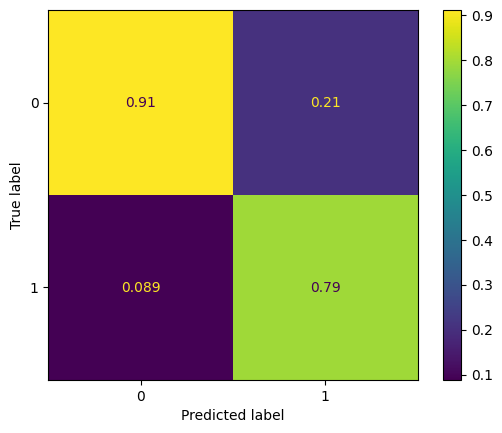

In [39]:
ConfusionMatrixDisplay(confusion_matrix(y_val, y_pred, labels=model.classes_, normalize='pred')).plot()

In [40]:
y_pred_train = model.predict_proba(X_train)
y_pred_train[:5]

array([[0.86, 0.14],
       [0.03, 0.97],
       [0.86, 0.14],
       [0.08, 0.92],
       [0.06, 0.94]])

In [41]:
y_pred_val = model.predict_proba(X_val)
y_pred_val[:5]

array([[0.14, 0.86],
       [0.79, 0.21],
       [0.27, 0.73],
       [0.25, 0.75],
       [0.39, 0.61]])

In [42]:
y_pred_test = model.predict_proba(X_test)
y_pred_test[:5]

array([[0.23, 0.77],
       [0.35, 0.65],
       [0.15, 0.85],
       [0.26, 0.74],
       [0.26, 0.74]])

In [43]:
feature_importances_df = pd.DataFrame({'Feature': model.feature_names_in_, 'Importance': model.feature_importances_})
len(feature_importances_df)

31345

In [44]:
feature_importances_df = feature_importances_df[feature_importances_df['Importance'] != 0]
len(feature_importances_df)

10589

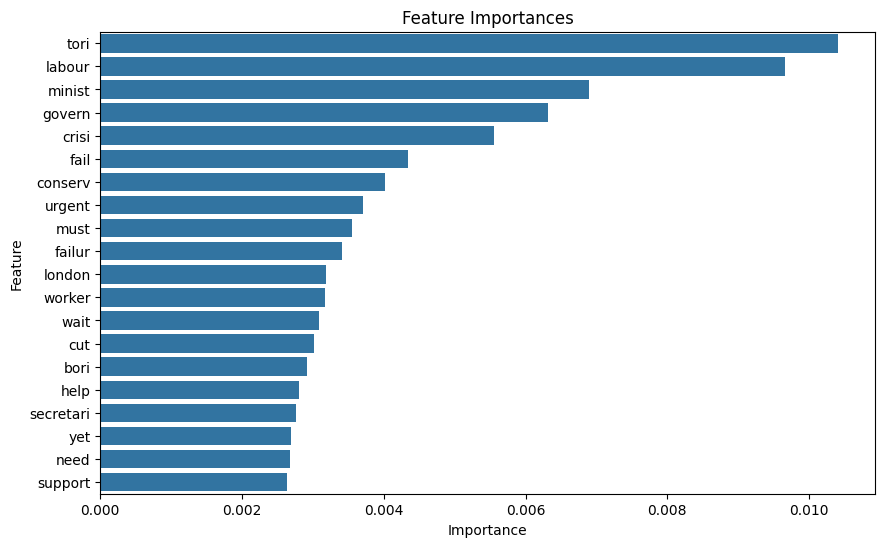

In [45]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances_df.sort_values('Importance', ascending=False).head(20), orient='h')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importances')
plt.show()

# Results analysis

In [46]:
def pred_to_df(preds, df):
    df['pred'] = [pred[1] for pred in preds]
    return df

In [47]:
train = pred_to_df(y_pred_train, train)
train.head()

,party,speech,pred
5483,0.0,year come hous work printer news world later s...,0.14
9621,1.0,earli depart educ chang way teacher qualifi ov...,0.97
3236,0.0,conserv stealth cut school budget show disrega...,0.14
4089,1.0,thank ask speak today british chamber commerc ...,0.92
8357,1.0,delight nottingham trent univers ntu morn make...,0.94


In [48]:
val = pred_to_df(y_pred_val, val)
val.head()

,party,speech,pred
5461,1.0,friday august million custom affect major powe...,0.86
8626,0.0,govern month sort exam forc screech day confus...,0.21
4041,1.0,rise today pay tribut behalf constitu alreadi ...,0.73
207,1.0,lord amend hous today relat nhs workforc recon...,0.75
4066,1.0,begin deputi speaker echo remark hon friend me...,0.61


In [49]:
test = pred_to_df(y_pred_test, test)
test.head()

,party,speech,pred
71,NaN,introduct thank point first cabinet minist hig...,0.77
73,NaN,subject open misunderstand misrepresent public...,0.65
74,NaN,introduct delight launch credit union stornowa...,0.85
76,NaN,wish updat hous progress reform public servic ...,0.74
79,NaN,good morn give great pleasur open breakfast me...,0.74


In [50]:
output = pd.concat([train, val, test], axis=0)
output.head()

,party,speech,pred
5483,0.0,year come hous work printer news world later s...,0.14
9621,1.0,earli depart educ chang way teacher qualifi ov...,0.97
3236,0.0,conserv stealth cut school budget show disrega...,0.14
4089,1.0,thank ask speak today british chamber commerc ...,0.92
8357,1.0,delight nottingham trent univers ntu morn make...,0.94


In [51]:
output = pd.merge(output, df_merged['Speaker'], left_index=True, right_index=True)
output

,party,speech,pred,Speaker
5483,0.0,year come hous work printer news world later s...,0.140,Ron Leighton
9621,1.0,earli depart educ chang way teacher qualifi ov...,0.970,Robin Walker
3236,0.0,conserv stealth cut school budget show disrega...,0.140,Kate Green
4089,1.0,thank ask speak today british chamber commerc ...,0.920,Michael Howard
8357,1.0,delight nottingham trent univers ntu morn make...,0.940,Chris Skidmore
...,...,...,...,...
9974,NaN,beg move leav given bring bill make provis hou...,0.690,Pete Wishart
9975,NaN,none minist acknowledg visa carnet render tour...,0.475,Pete Wishart
9977,NaN,thank madam deputi speaker heed appropri warn ...,0.610,John Woodcock
9978,NaN,privileg follow heartfelt speech also coincid ...,0.660,John Woodcock


In [52]:
df_speakers = pd.read_csv('./data/MPs_1970_onwards.csv')

In [53]:
df_speakers.drop_duplicates(subset='itemLabel', inplace=True)

In [54]:
df_speakers.rename(columns={'itemLabel': 'Speaker'}, inplace=True)
df_speakers.head()

,item,Speaker,constituencyLabel,partyLabel,start,electionLabel,end,endcauseLabel,noteLabel
0,http://www.wikidata.org/entity/Q265935,Nick Brown,Newcastle upon Tyne East,independent politician,2022-09-07T00:00:00Z,2019 United Kingdom general election,NaN,NaN,NaN
1,http://www.wikidata.org/entity/Q580464,Penny Mordaunt,NaN,NaN,2022-09-06T00:00:00Z,NaN,NaN,NaN,NaN
2,http://www.wikidata.org/entity/Q303299,Tobias Ellwood,Bournemouth East,independent politician,2022-07-19T00:00:00Z,NaN,NaN,NaN,NaN
3,http://www.wikidata.org/entity/Q575266,Christopher Pincher,Tamworth,independent politician,2022-06-30T00:00:00Z,NaN,NaN,NaN,NaN
4,http://www.wikidata.org/entity/Q19883135,Patrick Grady,Glasgow North,independent politician,2022-06-26T00:00:00Z,NaN,NaN,NaN,NaN


In [55]:
output_broken = pd.merge(output, df_speakers[['partyLabel', 'Speaker']], on='Speaker')
output_broken.head()

,party,speech,pred,Speaker,partyLabel
0,0.0,year come hous work printer news world later s...,0.14,Ron Leighton,Labour Party
1,1.0,earli depart educ chang way teacher qualifi ov...,0.97,Robin Walker,Conservative Party
2,0.0,conserv stealth cut school budget show disrega...,0.14,Kate Green,Labour Party
3,1.0,thank ask speak today british chamber commerc ...,0.92,Michael Howard,Conservative Party
4,1.0,delight nottingham trent univers ntu morn make...,0.94,Chris Skidmore,Conservative Party


In [56]:
# output_broken = output_broken[output_broken['partyLabel'] != 'Labour Party']
# output_broken = output_broken[output_broken['partyLabel'] != 'Conservative Party']
# output_broken.head()

In [57]:
grouped_parties = output_broken.groupby('partyLabel')['pred'].median().to_frame().reset_index()
grouped_parties

,partyLabel,pred
0,Alba Party,0.670000
1,Alliance Party of Northern Ireland,0.720000
2,Change UK,0.810000
3,Conservative Party,0.910000
4,Democratic Unionist Party,0.705000
5,Green Party of England and Wales,0.535000
6,Labour Co-operative,0.474917
7,Labour Party,0.210000
8,Liberal Democrats,0.680000
9,Liberal Party,0.680000


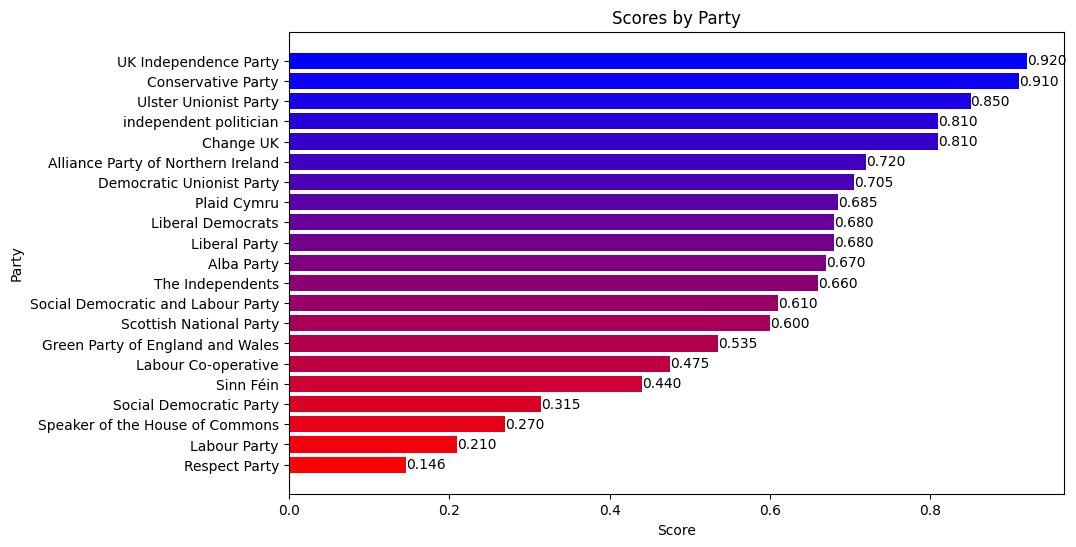

In [58]:
df = pd.DataFrame(grouped_parties)

df_sorted = df.sort_values(by='pred')

cmap = LinearSegmentedColormap.from_list('red_blue', [(1, 0, 0), (0, 0, 1)], N=len(df_sorted))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(df_sorted['partyLabel'], df_sorted['pred'], color=cmap(np.linspace(0, 1, len(df_sorted))))

for bar, pred in zip(bars, df_sorted['pred']):
    ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, f'{pred:.3f}', va='center', ha='left')

ax.set_xlabel('Score')
ax.set_ylabel('Party')
ax.set_title('Scores by Party')

plt.show()

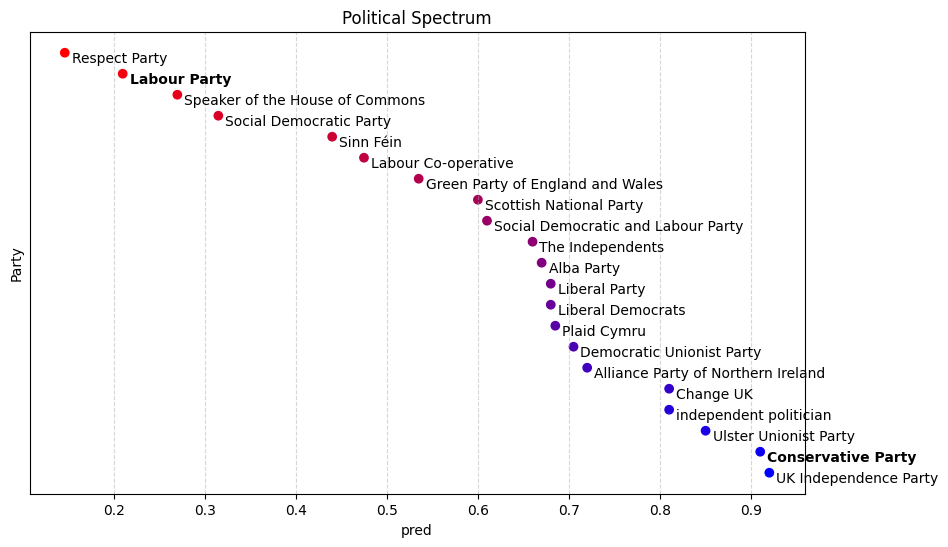

In [63]:
df = pd.DataFrame(grouped_parties)

df_sorted = df.sort_values(by='pred')

cmap = LinearSegmentedColormap.from_list('red_blue', [(1, 0, 0), (0, 0, 1)], N=len(df_sorted))

plt.figure(figsize=(10, 6))
plt.scatter(df_sorted['pred'], range(len(df_sorted)), c=range(len(df_sorted)), cmap=cmap)

for i, txt in enumerate(df_sorted['partyLabel']):
    if txt == 'Conservative Party' or txt == 'Labour Party':
        plt.annotate(txt, (df_sorted['pred'].iloc[i], i), xytext=(5, -7), textcoords='offset points', weight='bold')
    else:
        plt.annotate(txt, (df_sorted['pred'].iloc[i], i), xytext=(5, -7), textcoords='offset points')

plt.xlabel('pred')
plt.ylabel('Party')
plt.title('Political Spectrum')

plt.tick_params(axis='y', which='both', left=False, labelleft=False)  # Hide y-axis ticks and labels
plt.grid(axis='x', alpha=0.5, linestyle='--')

plt.gca().invert_yaxis()  # Reverse y-axis to have lowest preds on the left

plt.show()